In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\HP\Documents\Project For Data science\Dirty_Bakery_Dataset_Full.csv")

In [3]:
df.head()

,Date,Route_Name,Product_Category,Qty_Produced,Qty_Dispatched,Qty_Sold,Qty_Returned,Day_of_Week,School_Term_Status,Is_Payday_Period,Waste_Cost_Ksh
0,"May 01, 2026",Route-C,Cake,156,155,87.0,68,Friday,In session,0,NaN
1,01/05/2026,Route A,Bread,4760,466,376.0,90,Friday,In session,yes,4500
2,2026/05/02,Route-B,Bread,548,551,NaN,98,Saturday,Holiday,Na,4900
3,2026-05-02,Route-C,Mandazi,972,975,880.0,95,Saturday,in session,yes,4750
4,"May 03, 2026",Route B,Cakes,224,224,256.0,-32,Sunday,In Session,No,-1600


In [4]:
# dataset overview
# rows and columns
df.shape

(65, 11)

In [5]:
# info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                62 non-null     object 
 1   Route_Name          62 non-null     object 
 2   Product_Category    62 non-null     object 
 3   Qty_Produced        62 non-null     object 
 4   Qty_Dispatched      61 non-null     object 
 5   Qty_Sold            55 non-null     float64
 6   Qty_Returned        62 non-null     object 
 7   Day_of_Week         62 non-null     object 
 8   School_Term_Status  62 non-null     object 
 9   Is_Payday_Period    51 non-null     object 
 10  Waste_Cost_Ksh      58 non-null     object 
dtypes: float64(1), object(10)
memory usage: 5.7+ KB


In [6]:
df.describe()

,Qty_Sold
count,55.000000
mean,502.727273
std,355.765188
min,75.000000
25%,194.500000
50%,383.000000
75%,918.500000
max,1043.000000


In [7]:
# all variables names
df.columns

Index(['Date', 'Route_Name', 'Product_Category', 'Qty_Produced',
       'Qty_Dispatched', 'Qty_Sold', 'Qty_Returned', 'Day_of_Week',
       'School_Term_Status', 'Is_Payday_Period', 'Waste_Cost_Ksh'],
      dtype='object')

## Data Cleaning and Preparation

In [8]:
# check missing values
df.isnull().sum()

Date                   3
Route_Name             3
Product_Category       3
Qty_Produced           3
Qty_Dispatched         4
Qty_Sold              10
Qty_Returned           3
Day_of_Week            3
School_Term_Status     3
Is_Payday_Period      14
Waste_Cost_Ksh         7
dtype: int64

In [9]:
# replace dirty missing values
df.replace(
    ["?","null","Null","N/A","-",""],
    np.nan, inplace=True
)

In [10]:
df.isnull().sum()

Date                   3
Route_Name             3
Product_Category       3
Qty_Produced           3
Qty_Dispatched        12
Qty_Sold              10
Qty_Returned           6
Day_of_Week            3
School_Term_Status     3
Is_Payday_Period      14
Waste_Cost_Ksh         7
dtype: int64

In [11]:
df.Date.value_counts()

Date
2026-05-30      2
May 03, 2026    2
May 20, 2026    2
2026/05/06      2
May 01, 2026    1
24/05/2026      1
2026/05/18      1
May 18, 2026    1
May 19, 2026    1
2026-05-19      1
21/05/2026      1
May 21, 2026    1
22-05-2026      1
2026/05/22      1
23-05-2026      1
2026/05/23      1
2026-05-25      1
2026/05/24      1
May 17, 2026    1
May 25, 2026    1
2026/05/26      1
2026-05-26      1
May 27, 2026    1
27/05/2026      1
2026-05-28      1
May 28, 2026    1
May 29, 2026    1
2026/05/29      1
2026-05-31      1
17/05/2026      1
2026/05/16      1
01/05/2026      1
2026/05/09      1
2026/05/02      1
2026-05-02      1
04-05-2026      1
2026/05/04      1
05-05-2026      1
05/05/2026      1
2026/05/07      1
07-05-2026      1
May 08, 2026    1
08-05-2026      1
09-05-2026      1
May 10, 2026    1
16/05/2026      1
10/05/2026      1
11/05/2026      1
May 11, 2026    1
12/05/2026      1
2026/05/12      1
2026-05-13      1
May 13, 2026    1
14-05-2026      1
2026/05/14      1
15/05

In [12]:
# convert date into one format
df['Date']=pd.to_datetime(df['Date'], format='mixed',dayfirst=True)

In [13]:
df['Date'].dtype

dtype('<M8[ns]')

In [14]:
df.Date.value_counts()

Date
2026-05-01    2
2026-05-17    2
2026-05-30    2
2026-05-29    2
2026-05-28    2
2026-05-27    2
2026-05-26    2
2026-05-25    2
2026-05-24    2
2026-05-23    2
2026-05-22    2
2026-05-21    2
2026-05-20    2
2026-05-19    2
2026-05-18    2
2026-05-16    2
2026-05-02    2
2026-05-15    2
2026-05-14    2
2026-05-13    2
2026-05-12    2
2026-05-11    2
2026-05-10    2
2026-05-09    2
2026-05-08    2
2026-05-07    2
2026-05-06    2
2026-05-05    2
2026-05-04    2
2026-05-03    2
2026-05-31    2
Name: count, dtype: int64

In [15]:
df.isnull().sum()

Date                   3
Route_Name             3
Product_Category       3
Qty_Produced           3
Qty_Dispatched        12
Qty_Sold              10
Qty_Returned           6
Day_of_Week            3
School_Term_Status     3
Is_Payday_Period      14
Waste_Cost_Ksh         7
dtype: int64

In [16]:
df.Route_Name.value_counts()

Route_Name
Route A     9
Route-C     8
Route-B     6
Route C     6
route b     6
Route B     5
Route A     5
Route B     4
route a     4
Route C     4
Route-A     3
route c     2
Name: count, dtype: int64

In [17]:
df.Route_Name=df.Route_Name.replace({'route a':'Route-A','Route A':'Route-A','route b':'Route-B','Route B':'Route-B','Route C':'Route-C','route c':'Route-C'})

In [18]:
df.Route_Name.value_counts()

Route_Name
Route-A     16
Route-B     16
Route-C     14
Route C      6
Route B      5
Route A      5
Name: count, dtype: int64

In [19]:
df.Route_Name=df.Route_Name.replace({'Route A':'Route-A','Route B':'Route-B','Route C':'Route-C'})

In [20]:
df.Route_Name.value_counts()

Route_Name
Route-A     16
Route-B     16
Route-C     14
Route C      6
Route B      5
Route A      5
Name: count, dtype: int64

In [21]:
df.isnull().sum()

Date                   3
Route_Name             3
Product_Category       3
Qty_Produced           3
Qty_Dispatched        12
Qty_Sold              10
Qty_Returned           6
Day_of_Week            3
School_Term_Status     3
Is_Payday_Period      14
Waste_Cost_Ksh         7
dtype: int64

In [22]:
df.Date=df.Date.ffill()

In [23]:
df.Route_Name=df.Route_Name.ffill()

In [24]:
df.Product_Category=df.Product_Category.ffill()

In [25]:
df.Qty_Produced=df.Qty_Produced.ffill()

In [26]:
df.Qty_Dispatched=df.Qty_Dispatched.ffill()

In [27]:
df.Qty_Sold=df.Qty_Sold.ffill()

In [28]:
df.Qty_Returned=df.Qty_Returned.ffill()

In [29]:
df.Day_of_Week=df.Day_of_Week.ffill()

In [30]:
df.School_Term_Status=df.School_Term_Status.ffill()

In [31]:
df.Is_Payday_Period=df.Is_Payday_Period .ffill()

In [32]:
df.Waste_Cost_Ksh=df.Waste_Cost_Ksh.ffill()

In [33]:
df.isnull().sum()

Date                  0
Route_Name            0
Product_Category      0
Qty_Produced          0
Qty_Dispatched        0
Qty_Sold              0
Qty_Returned          0
Day_of_Week           0
School_Term_Status    0
Is_Payday_Period      0
Waste_Cost_Ksh        1
dtype: int64

In [34]:
df.Waste_Cost_Ksh=df.Waste_Cost_Ksh.bfill()

In [35]:
df.isnull().sum()

Date                  0
Route_Name            0
Product_Category      0
Qty_Produced          0
Qty_Dispatched        0
Qty_Sold              0
Qty_Returned          0
Day_of_Week           0
School_Term_Status    0
Is_Payday_Period      0
Waste_Cost_Ksh        0
dtype: int64

In [36]:
#filling values of categorical columns

In [37]:
df.Route_Name.value_counts()

Route_Name
Route-A     19
Route-B     16
Route-C     14
Route C      6
Route B      5
Route A      5
Name: count, dtype: int64

In [38]:
df['Route_Name'] = df['Route_Name'].replace({'Route A': 'Route-A','Route B': 'Route-B','Route C': 'Route-C'})

In [39]:
df.Route_Name.value_counts()

Route_Name
Route-A     19
Route-B     16
Route-C     14
Route C      6
Route B      5
Route A      5
Name: count, dtype: int64

In [40]:
df['Route_Name'] = ( df['Route_Name'].str.strip().str.replace(' ', '-', regex=False))

In [41]:
df.Route_Name.value_counts()

Route_Name
Route-A    24
Route-B    21
Route-C    20
Name: count, dtype: int64

In [42]:
df.Product_Category.value_counts()

Product_Category
Cake        17
Mandazi     12
Cakes        8
Bread        8
 Bread       6
mandazis     5
bread        5
Mandazis     4
Name: count, dtype: int64

In [43]:
df['Product_Category'] = df['Product_Category'].replace({'Cakes': 'Cake','Bread': 'Bread','bread': 'Bread', 'mandazis': 'Mandazi', 'Mandazis': 'Mandazi'})

In [44]:
df.Product_Category.value_counts()

Product_Category
Cake       25
Mandazi    21
Bread      13
 Bread      6
Name: count, dtype: int64

In [45]:
df['Product_Category'] = (df['Product_Category'].str.strip())

In [46]:
df.Product_Category.value_counts()

Product_Category
Cake       25
Mandazi    21
Bread      19
Name: count, dtype: int64

In [47]:
df.Day_of_Week.value_counts()

Day_of_Week
Sunday       11
Friday        9
Saturday      8
Monday        8
Wednesday     8
Thursday      7
Tuesday       6
tuesday       2
Sun           1
friday        1
sunday        1
sat           1
thursday      1
saturday      1
Name: count, dtype: int64

In [48]:
df['Day_of_Week'] = df['Day_of_Week'].replace({'tuesday':'Tuesday','friday':'Friday','sunday':'Sunday','thursday':'Thursday','saturday':'Saturday','Sun':'Sunday','sat':'Saturday'})

In [49]:
df.Day_of_Week.value_counts()

Day_of_Week
Sunday       13
Friday       10
Saturday     10
Monday        8
Tuesday       8
Wednesday     8
Thursday      8
Name: count, dtype: int64

In [50]:
df.School_Term_Status.value_counts()

School_Term_Status
in session    17
In session    14
Break         10
Holiday        8
In Session     8
Hols           8
Name: count, dtype: int64

In [51]:
df['School_Term_Status'] = df['School_Term_Status'].replace({'in session': 'In Session','In session': 'In Session','Hols': 'Holiday'})

In [52]:
df.School_Term_Status.value_counts()

School_Term_Status
In Session    39
Holiday       16
Break         10
Name: count, dtype: int64

In [53]:
df.Is_Payday_Period.value_counts()

Is_Payday_Period
0      16
Yes    11
no     10
yes     9
Na      8
1       6
No      5
Name: count, dtype: int64

In [54]:
df['Is_Payday_Period'] = df['Is_Payday_Period'].replace({'1': 'Yes','0': 'No','yes': 'Yes','no': 'No','Na': 'N/A'})

In [55]:
df.Is_Payday_Period.value_counts()

Is_Payday_Period
No     31
Yes    26
N/A     8
Name: count, dtype: int64

In [56]:
#filling missing values of numeric columns

In [57]:
df.isnull().sum()

Date                  0
Route_Name            0
Product_Category      0
Qty_Produced          0
Qty_Dispatched        0
Qty_Sold              0
Qty_Returned          0
Day_of_Week           0
School_Term_Status    0
Is_Payday_Period      0
Waste_Cost_Ksh        0
dtype: int64

In [58]:
df[['Qty_Produced', 'Qty_Dispatched', 'Qty_Sold', 'Qty_Returned']].isnull().sum()

Qty_Produced      0
Qty_Dispatched    0
Qty_Sold          0
Qty_Returned      0
dtype: int64

In [59]:
# check the datatypes
df[['Qty_Produced', 'Qty_Dispatched', 'Qty_Sold', 'Qty_Returned','Waste_Cost_Ksh']].dtypes

Qty_Produced       object
Qty_Dispatched     object
Qty_Sold          float64
Qty_Returned       object
Waste_Cost_Ksh     object
dtype: object

In [60]:
num_cols = ['Qty_Produced', 'Qty_Dispatched', 'Qty_Sold', 'Qty_Returned','Waste_Cost_Ksh']

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r'[^0-9.]', '', regex=True)
    )

In [61]:
# converting all to numeric
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [62]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [63]:
df[num_cols].head(20)

,Qty_Produced,Qty_Dispatched,Qty_Sold,Qty_Returned,Waste_Cost_Ksh
0,156,155,87.0,68,4500
1,4760,466,376.0,90,4500
2,548,551,376.0,98,4900
3,972,975,880.0,95,4750
4,224,224,256.0,32,1600
5,550,543,586.0,43,2150
6,988,984,586.0,5,250
7,154,150,75.0,75,3750
8,1034,1044,990.0,54,2700
9,166,161,159.0,2,100


In [64]:
df[num_cols].isnull().sum()

Qty_Produced      0
Qty_Dispatched    0
Qty_Sold          0
Qty_Returned      0
Waste_Cost_Ksh    0
dtype: int64

In [65]:
#check the disribution
df[num_cols].describe()

,Qty_Produced,Qty_Dispatched,Qty_Sold,Qty_Returned,Waste_Cost_Ksh
count,65.000000,65.000000,65.000000,65.000000,65.000000
mean,1204.661538,504.876923,500.892308,52.123077,2563.846154
std,2368.979667,351.226134,348.113807,29.929870,1501.913043
min,151.000000,150.000000,75.000000,2.000000,100.000000
25%,219.000000,202.000000,194.000000,31.000000,1550.000000
50%,488.000000,450.000000,383.000000,51.000000,2500.000000
75%,988.000000,970.000000,904.000000,76.000000,3800.000000
max,10060.000000,1054.000000,1043.000000,98.000000,4900.000000


In [66]:
# remove duplicate records
df.duplicated().sum()

np.int64(3)

In [67]:
df = df.drop_duplicates()

In [68]:
## detecting Outliers
Q1 = df["Qty_Sold"].quantile(0.25)
Q3 = df["Qty_Sold"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[
    (df["Qty_Sold"] < lower) |
    (df["Qty_Sold"] > upper)
]

In [69]:
outliers

,Date,Route_Name,Product_Category,Qty_Produced,Qty_Dispatched,Qty_Sold,Qty_Returned,Day_of_Week,School_Term_Status,Is_Payday_Period,Waste_Cost_Ksh


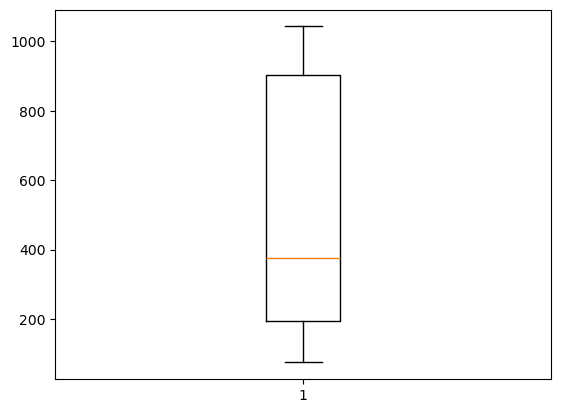

In [70]:
plt.boxplot(df["Qty_Sold"])

plt.show()

## Feature Engineering

In [71]:
# waste ratio
df["Waste_ratio"] = (df["Qty_Returned"] / df["Qty_Dispatched"])

In [72]:
# fulfillment rate
df["Fulfillment_Rate"] = (df["Qty_Sold"] / df["Qty_Dispatched"])

In [73]:
# production Efficiency
df["Production_Efficiency"] = (df["Qty_Sold"] /df["Qty_Produced"])

In [74]:
# weekend
df["Is_Weekend"] = (df["Day_of_Week"].isin(["Saturday","Sunday"]))

In [75]:
# month
df["Month"] = (df["Date"].dt.month_name())

In [76]:
# save a clean dataset
df.to_csv("Clean_Bakery_Dataset.csv", index=False)

In [77]:
df.head()

,Date,Route_Name,Product_Category,Qty_Produced,Qty_Dispatched,Qty_Sold,Qty_Returned,Day_of_Week,School_Term_Status,Is_Payday_Period,Waste_Cost_Ksh,Waste_ratio,Fulfillment_Rate,Production_Efficiency,Is_Weekend,Month
0,2026-05-01,Route-C,Cake,156,155,87.0,68,Friday,In Session,No,4500,0.438710,0.561290,0.557692,False,May
1,2026-05-01,Route-A,Bread,4760,466,376.0,90,Friday,In Session,Yes,4500,0.193133,0.806867,0.078992,False,May
2,2026-05-02,Route-B,Bread,548,551,376.0,98,Saturday,Holiday,N/A,4900,0.177858,0.682396,0.686131,True,May
3,2026-05-02,Route-C,Mandazi,972,975,880.0,95,Saturday,In Session,Yes,4750,0.097436,0.902564,0.905350,True,May
4,2026-05-03,Route-B,Cake,224,224,256.0,32,Sunday,In Session,No,1600,0.142857,1.142857,1.142857,True,May


# Exploratory Data Analysis EDA

In [78]:
df = pd.read_csv("Clean_Bakery_Dataset.csv")

In [79]:
df.head(10)

,Date,Route_Name,Product_Category,Qty_Produced,Qty_Dispatched,Qty_Sold,Qty_Returned,Day_of_Week,School_Term_Status,Is_Payday_Period,Waste_Cost_Ksh,Waste_ratio,Fulfillment_Rate,Production_Efficiency,Is_Weekend,Month
0,2026-05-01,Route-C,Cake,156,155,87.0,68,Friday,In Session,No,4500,0.438710,0.561290,0.557692,False,May
1,2026-05-01,Route-A,Bread,4760,466,376.0,90,Friday,In Session,Yes,4500,0.193133,0.806867,0.078992,False,May
2,2026-05-02,Route-B,Bread,548,551,376.0,98,Saturday,Holiday,NaN,4900,0.177858,0.682396,0.686131,True,May
3,2026-05-02,Route-C,Mandazi,972,975,880.0,95,Saturday,In Session,Yes,4750,0.097436,0.902564,0.905350,True,May
4,2026-05-03,Route-B,Cake,224,224,256.0,32,Sunday,In Session,No,1600,0.142857,1.142857,1.142857,True,May
5,2026-05-03,Route-C,Bread,550,543,586.0,43,Sunday,Break,No,2150,0.079190,1.079190,1.065455,True,May
6,2026-05-04,Route-B,Mandazi,988,984,586.0,5,Monday,In Session,Yes,250,0.005081,0.595528,0.593117,False,May
7,2026-05-04,Route-C,Cake,154,150,75.0,75,Monday,Break,Yes,3750,0.500000,0.500000,0.487013,False,May
8,2026-05-05,Route-A,Mandazi,1034,1044,990.0,54,Tuesday,Break,Yes,2700,0.051724,0.948276,0.957447,False,May
9,2026-05-05,Route-C,Cake,166,161,159.0,2,Tuesday,Holiday,Yes,100,0.012422,0.987578,0.957831,False,May


In [80]:
# Number of rows and columns
df.shape

(62, 16)

In [81]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   62 non-null     object 
 1   Route_Name             62 non-null     object 
 2   Product_Category       62 non-null     object 
 3   Qty_Produced           62 non-null     int64  
 4   Qty_Dispatched         62 non-null     int64  
 5   Qty_Sold               62 non-null     float64
 6   Qty_Returned           62 non-null     int64  
 7   Day_of_Week            62 non-null     object 
 8   School_Term_Status     62 non-null     object 
 9   Is_Payday_Period       54 non-null     object 
 10  Waste_Cost_Ksh         62 non-null     int64  
 11  Waste_ratio            62 non-null     float64
 12  Fulfillment_Rate       62 non-null     float64
 13  Production_Efficiency  62 non-null     float64
 14  Is_Weekend             62 non-null     bool   
 15  Month   

In [82]:
# Check for remaining missing values
df.isnull().sum()

Date                     0
Route_Name               0
Product_Category         0
Qty_Produced             0
Qty_Dispatched           0
Qty_Sold                 0
Qty_Returned             0
Day_of_Week              0
School_Term_Status       0
Is_Payday_Period         8
Waste_Cost_Ksh           0
Waste_ratio              0
Fulfillment_Rate         0
Production_Efficiency    0
Is_Weekend               0
Month                    0
dtype: int64

In [83]:
df.Is_Payday_Period.value_counts()

Is_Payday_Period
No     28
Yes    26
Name: count, dtype: int64

In [84]:
df.Is_Payday_Period=df.Is_Payday_Period .ffill()

In [85]:
df.isnull().sum()

Date                     0
Route_Name               0
Product_Category         0
Qty_Produced             0
Qty_Dispatched           0
Qty_Sold                 0
Qty_Returned             0
Day_of_Week              0
School_Term_Status       0
Is_Payday_Period         0
Waste_Cost_Ksh           0
Waste_ratio              0
Fulfillment_Rate         0
Production_Efficiency    0
Is_Weekend               0
Month                    0
dtype: int64

In [86]:
df.head()

,Date,Route_Name,Product_Category,Qty_Produced,Qty_Dispatched,Qty_Sold,Qty_Returned,Day_of_Week,School_Term_Status,Is_Payday_Period,Waste_Cost_Ksh,Waste_ratio,Fulfillment_Rate,Production_Efficiency,Is_Weekend,Month
0,2026-05-01,Route-C,Cake,156,155,87.0,68,Friday,In Session,No,4500,0.438710,0.561290,0.557692,False,May
1,2026-05-01,Route-A,Bread,4760,466,376.0,90,Friday,In Session,Yes,4500,0.193133,0.806867,0.078992,False,May
2,2026-05-02,Route-B,Bread,548,551,376.0,98,Saturday,Holiday,Yes,4900,0.177858,0.682396,0.686131,True,May
3,2026-05-02,Route-C,Mandazi,972,975,880.0,95,Saturday,In Session,Yes,4750,0.097436,0.902564,0.905350,True,May
4,2026-05-03,Route-B,Cake,224,224,256.0,32,Sunday,In Session,No,1600,0.142857,1.142857,1.142857,True,May


In [87]:
# Descriptive Statitistics
df.describe()

,Qty_Produced,Qty_Dispatched,Qty_Sold,Qty_Returned,Waste_Cost_Ksh,Waste_ratio,Fulfillment_Rate,Production_Efficiency
count,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000
mean,776.177419,521.661290,481.387097,49.951613,2453.225806,0.149112,1.097626,0.830415
std,1358.265318,351.031031,344.622643,28.913907,1448.172137,0.134327,1.004047,0.259817
min,151.000000,150.000000,75.000000,2.000000,100.000000,0.005081,0.082505,0.078992
25%,217.500000,214.250000,194.000000,31.000000,1437.500000,0.049903,0.770537,0.733599
50%,477.000000,456.500000,376.000000,50.000000,2475.000000,0.095166,0.932483,0.917020
75%,981.000000,970.000000,902.500000,73.000000,3737.500000,0.196002,1.019068,0.989438
max,10060.000000,1054.000000,1043.000000,98.000000,4900.000000,0.613924,5.721519,1.303226


In [88]:
# mean
df.mean(numeric_only=True)

Qty_Produced              776.177419
Qty_Dispatched            521.661290
Qty_Sold                  481.387097
Qty_Returned               49.951613
Waste_Cost_Ksh           2453.225806
Waste_ratio                 0.149112
Fulfillment_Rate            1.097626
Production_Efficiency       0.830415
Is_Weekend                  0.322581
dtype: float64

In [89]:
# median
df.median(numeric_only=True)

Qty_Produced              477.000000
Qty_Dispatched            456.500000
Qty_Sold                  376.000000
Qty_Returned               50.000000
Waste_Cost_Ksh           2475.000000
Waste_ratio                 0.095166
Fulfillment_Rate            0.932483
Production_Efficiency       0.917020
Is_Weekend                  0.000000
dtype: float64

In [90]:
# variance
df.var(numeric_only=True)

Qty_Produced             1.844885e+06
Qty_Dispatched           1.232228e+05
Qty_Sold                 1.187648e+05
Qty_Returned             8.360140e+02
Waste_Cost_Ksh           2.097203e+06
Waste_ratio              1.804376e-02
Fulfillment_Rate         1.008110e+00
Production_Efficiency    6.750493e-02
Is_Weekend               2.221047e-01
dtype: float64

In [91]:
# Standard Deviation
df.std(numeric_only=True)

Qty_Produced             1358.265318
Qty_Dispatched            351.031031
Qty_Sold                  344.622643
Qty_Returned               28.913907
Waste_Cost_Ksh           1448.172137
Waste_ratio                 0.134327
Fulfillment_Rate            1.004047
Production_Efficiency       0.259817
Is_Weekend                  0.471280
dtype: float64

In [92]:
# distribution of Numeric Variables
numeric_columns = ["Qty_Produced","Qty_Dispatched","Qty_Sold","Qty_Returned","Waste_Cost_Ksh"]

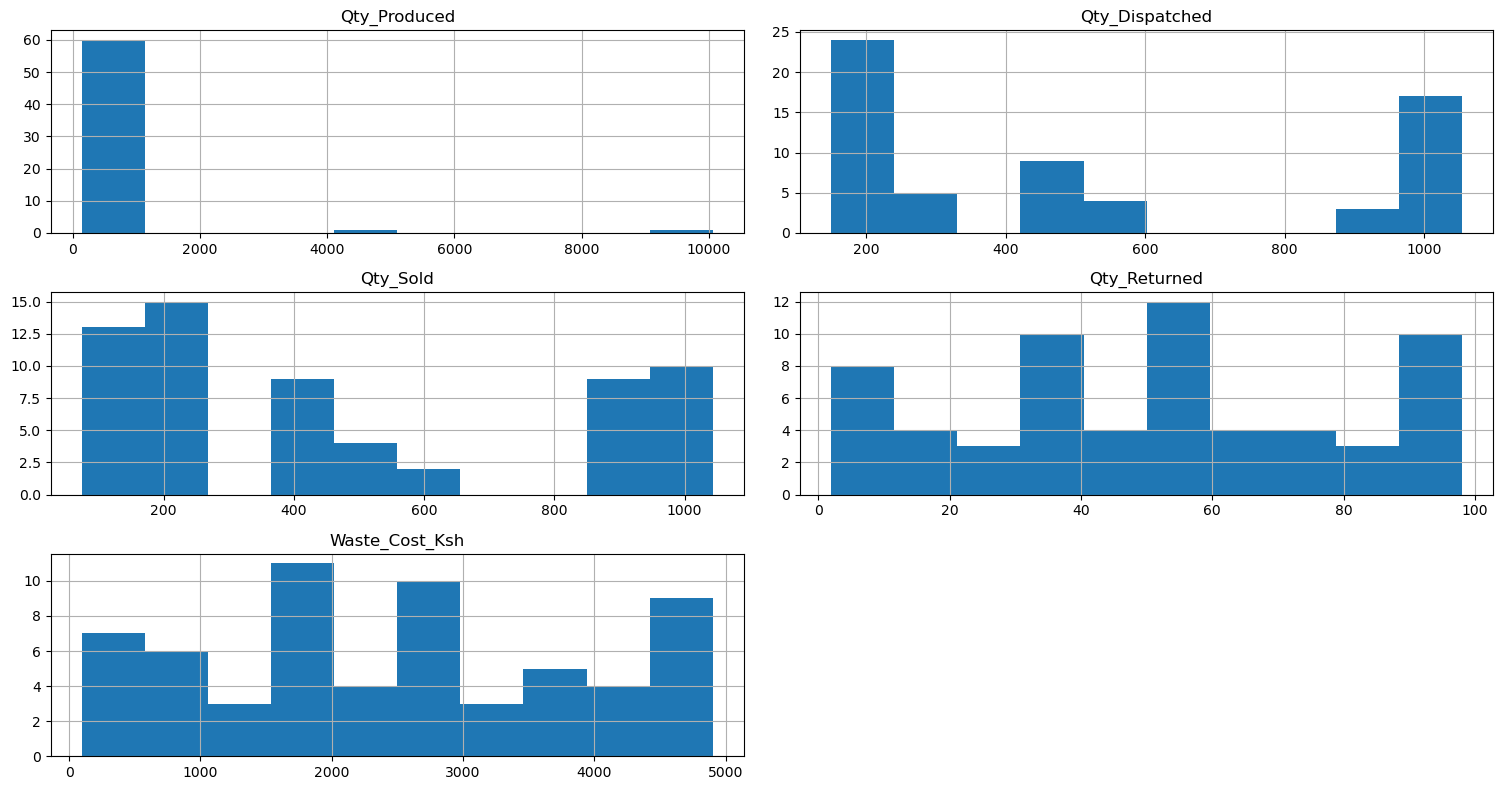

In [93]:
df[numeric_columns].hist(figsize=(15,8))

plt.tight_layout()
plt.show()

### Interpretation of Numeric variables

The histograms reveal that the numerical variables are generally not normally distributed. Qty_Produced is highly positively skewed and contains extreme high values. Qty_Dispatched and Qty_Sold exhibit bimodal distributions, suggesting the presence of two distinct groups or production patterns within the dataset. Qty_Returned and Waste_Cost_Ksh also display irregular distributions rather than the symmetric bell-shaped pattern expected under normality. These findings suggest that further analysis, such as box plots and correlation analysis, should be performed to better understand outliers and relationships among the variables.

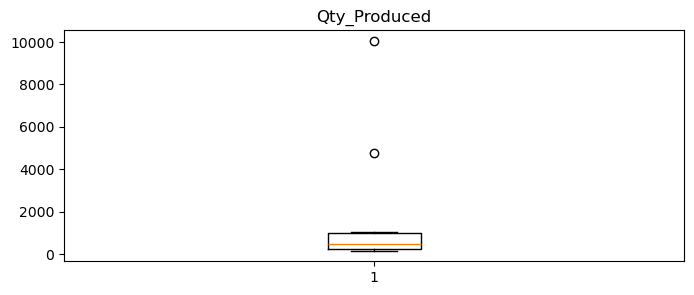

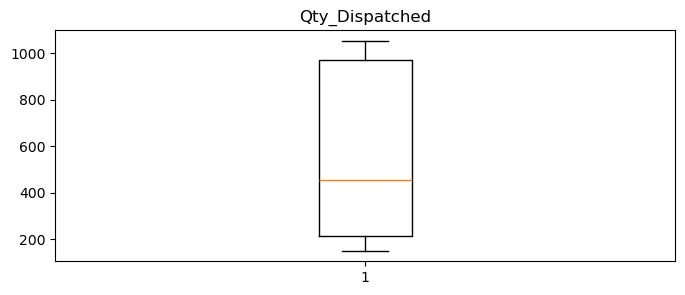

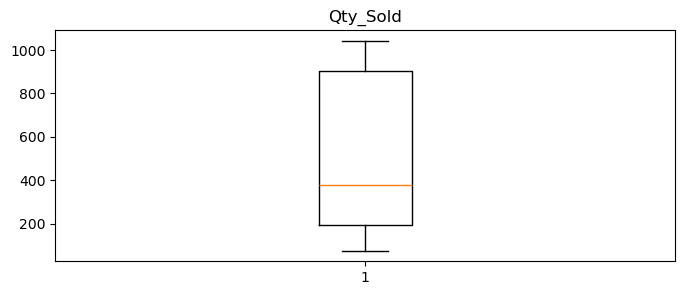

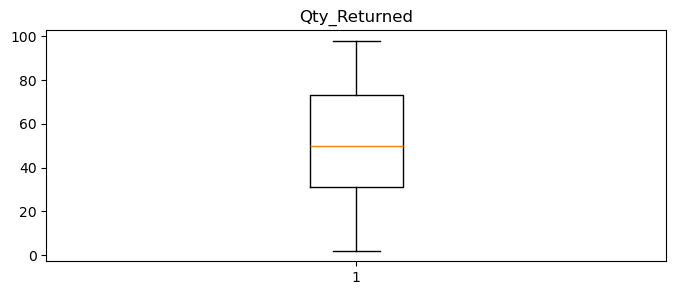

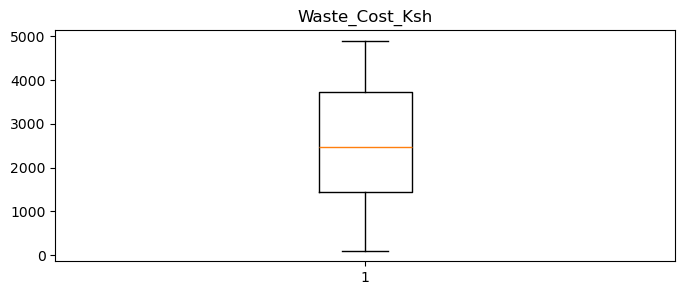

In [94]:
for col in numeric_columns:
    plt.figure(figsize=(8,3))
    plt.boxplot(df[col])
    plt.title(col)
    plt.show()

# interpretation of boxplots
The box plots indicate that Qty_Produced contains two prominent outliers, suggesting the presence of unusually high production values. These observations may represent either recording errors or genuine periods of exceptionally high production and should therefore be investigated before any data cleaning decisions are made. The remaining variables (Qty_Dispatched, Qty_Sold, Qty_Returned, and Waste_Cost_Ksh) do not exhibit significant outliers, indicating relatively consistent distributions without extreme observations. Overall, the dataset appears to contain only a small number of unusual values, with Qty_Produced being the primary variable requiring further examination.

In [95]:
# correlation Analysis
numericals= df[numeric_columns].corr()

In [96]:
numericals

,Qty_Produced,Qty_Dispatched,Qty_Sold,Qty_Returned,Waste_Cost_Ksh
Qty_Produced,1.000000,0.087123,0.351938,0.257781,0.278858
Qty_Dispatched,0.087123,1.000000,0.666356,0.021722,0.077185
Qty_Sold,0.351938,0.666356,1.000000,0.010757,0.068355
Qty_Returned,0.257781,0.021722,0.010757,1.000000,0.853242
Waste_Cost_Ksh,0.278858,0.077185,0.068355,0.853242,1.000000


In [97]:
numericals.corr()

,Qty_Produced,Qty_Dispatched,Qty_Sold,Qty_Returned,Waste_Cost_Ksh
Qty_Produced,1.000000,-0.479011,-0.076847,-0.133340,-0.147428
Qty_Dispatched,-0.479011,1.000000,0.809351,-0.796770,-0.775242
Qty_Sold,-0.076847,0.809351,1.000000,-0.916569,-0.898386
Qty_Returned,-0.133340,-0.796770,-0.916569,1.000000,0.973698
Waste_Cost_Ksh,-0.147428,-0.775242,-0.898386,0.973698,1.000000


In [112]:
import scipy
from scipy import stats as st
st.pearsonr(df.Qty_Produced, df.Qty_Dispatched)

PearsonRResult(statistic=np.float64(0.0871226023063458), pvalue=np.float64(0.5007404170270848))

In [113]:
df.describe()

,Qty_Produced,Qty_Dispatched,Qty_Sold,Qty_Returned,Waste_Cost_Ksh,Waste_ratio,Fulfillment_Rate,Production_Efficiency
count,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000
mean,776.177419,521.661290,481.387097,49.951613,2453.225806,0.149112,1.097626,0.830415
std,1358.265318,351.031031,344.622643,28.913907,1448.172137,0.134327,1.004047,0.259817
min,151.000000,150.000000,75.000000,2.000000,100.000000,0.005081,0.082505,0.078992
25%,217.500000,214.250000,194.000000,31.000000,1437.500000,0.049903,0.770537,0.733599
50%,477.000000,456.500000,376.000000,50.000000,2475.000000,0.095166,0.932483,0.917020
75%,981.000000,970.000000,902.500000,73.000000,3737.500000,0.196002,1.019068,0.989438
max,10060.000000,1054.000000,1043.000000,98.000000,4900.000000,0.613924,5.721519,1.303226


<Axes: ylabel='Qty_Dispatched'>

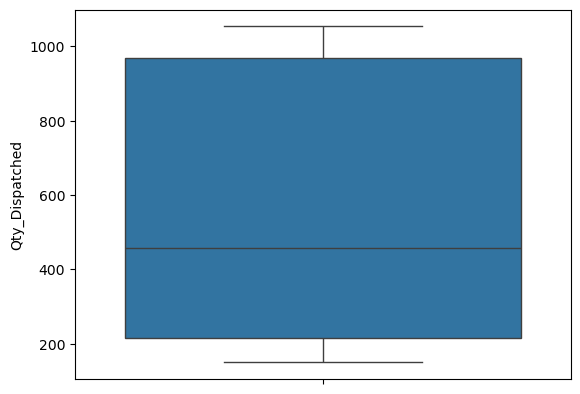

In [114]:
sns.boxplot(y ='Qty_Dispatched', data = df)

In [115]:
Q3 = df.Qty_Dispatched.quantile(0.75)
print(Q3)

970.0


In [116]:
Q1 = df.Qty_Dispatched.quantile(0.25)
print(Q1)

214.25


In [117]:
IQR = Q3 - Q1
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

In [119]:
df[(df['Qty_Dispatched'] < lower_limit) | (df['Qty_Dispatched'] > upper_limit)]

,Date,Route_Name,Product_Category,Qty_Produced,Qty_Dispatched,Qty_Sold,Qty_Returned,Day_of_Week,School_Term_Status,Is_Payday_Period,Waste_Cost_Ksh,Waste_ratio,Fulfillment_Rate,Production_Efficiency,Is_Weekend,Month


<Axes: ylabel='Qty_Dispatched'>

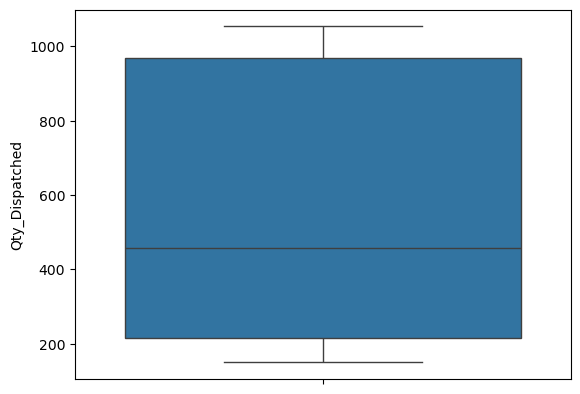

In [120]:
sns.boxplot(y ='Qty_Dispatched', data = df)

<Axes: >

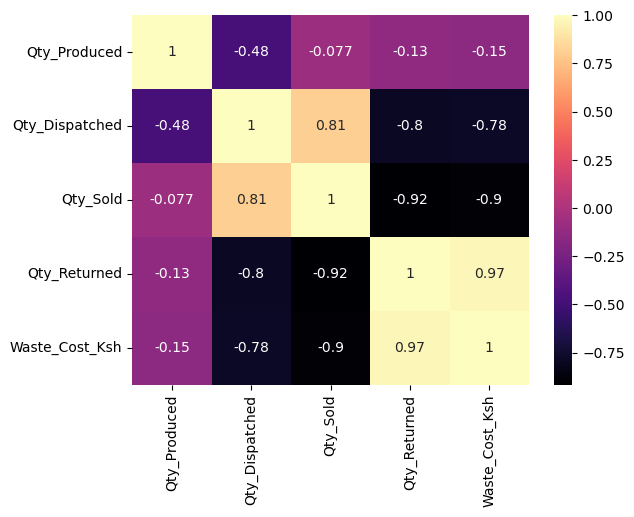

In [125]:
sns.heatmap(numericals.corr(), annot= True, cmap ='magma')